# Notebook 04 — Escolaridade dos pais × desempenho
**Eixo de análise:** Gustavo Silveira Goulart  
**Pergunta:** Como a escolaridade dos pais influencia o desempenho do estudante no ENEM?

Análise das variáveis **Q001 (pai)** e **Q002 (mãe)** em relação às notas, com recortes por:
- Estado (RS vs SP)
- Ano (2019 vs 2023, pré e pós-pandemia)
- Comparação entre o efeito da escolaridade do pai vs da mãe
- Área de conhecimento

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Carrega e une os dois anos
df_2019 = pd.read_parquet('/content/drive/MyDrive/enem-dados/enem2019_RS_SP.parquet')
df_2023 = pd.read_parquet('/content/drive/MyDrive/enem-dados/enem2023_RS_SP.parquet')
df = pd.concat([df_2019, df_2023], ignore_index=True)

# Filtro de presença nos 2 dias
presentes = (df['TP_PRESENCA_CN']==1) & (df['TP_PRESENCA_CH']==1) & \
            (df['TP_PRESENCA_LC']==1) & (df['TP_PRESENCA_MT']==1)
df = df[presentes].copy()

# Nota média
areas = ['NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO']
df['NOTA_MEDIA'] = df[areas].mean(axis=1)

print(f"Base de análise: {len(df):,} participantes presentes nos 2 dias")

Base de análise: 1,258,720 participantes presentes nos 2 dias


## Sobre as variáveis Q001 (pai) e Q002 (mãe)

Ambas usam a mesma escala — escolaridade do responsável pelo participante:

| Código | Escolaridade |
|---|---|
| A | Nunca estudou |
| B | Não completou a 4ª série / 5º ano EF |
| C | Completou a 4ª série, mas não a 8ª / 9º ano EF |
| D | Completou a 8ª série / 9º ano, mas não o ensino médio |
| E | Completou ensino médio, mas não a faculdade |
| F | Completou a faculdade, mas não a pós-graduação |
| G | Completou pós-graduação |
| H | Não sei |

**Observação:** o código `H` (Não sei) será tratado como categoria separada.

In [3]:
# Distribuição da escolaridade do pai e da mãe
ordem = list('ABCDEFGH')

print("Distribuição da escolaridade do PAI (Q001):")
print(df['Q001'].value_counts().reindex(ordem))
print("\nDistribuição da escolaridade da MÃE (Q002):")
print(df['Q002'].value_counts().reindex(ordem))

Distribuição da escolaridade do PAI (Q001):
Q001
A     22694
B    154628
C    150664
D    147019
E    415851
F    171446
G    108669
H     87749
Name: count, dtype: int64

Distribuição da escolaridade da MÃE (Q002):
Q002
A     16971
B    113044
C    124757
D    146210
E    467482
F    210510
G    155374
H     24372
Name: count, dtype: int64


## 1. Nota média por escolaridade dos pais — pai e mãe lado a lado

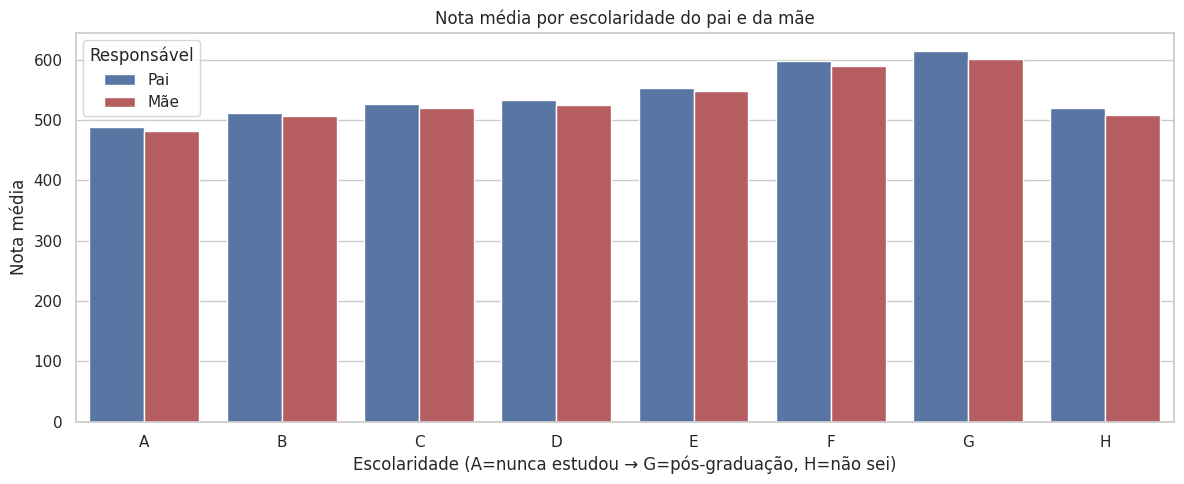

In [4]:
# Calcula médias para pai e mãe
medias_pai = df.groupby('Q001')['NOTA_MEDIA'].mean().reindex(ordem).reset_index()
medias_pai.columns = ['Escolaridade','Nota_média']
medias_pai['Responsável'] = 'Pai'

medias_mae = df.groupby('Q002')['NOTA_MEDIA'].mean().reindex(ordem).reset_index()
medias_mae.columns = ['Escolaridade','Nota_média']
medias_mae['Responsável'] = 'Mãe'

medias = pd.concat([medias_pai, medias_mae], ignore_index=True)

fig, ax = plt.subplots(figsize=(12,5))
sns.barplot(data=medias, x='Escolaridade', y='Nota_média', hue='Responsável',
            palette=['#4C72B0','#C44E52'], ax=ax, order=ordem)
ax.set_title('Nota média por escolaridade do pai e da mãe')
ax.set_xlabel('Escolaridade (A=nunca estudou → G=pós-graduação, H=não sei)')
ax.set_ylabel('Nota média')
plt.tight_layout()
plt.show()

In [5]:
# Tabela comparativa: efeito do pai vs efeito da mãe
tabela = pd.DataFrame({
    'Escolaridade': ordem,
    'Nota_média_pai': df.groupby('Q001')['NOTA_MEDIA'].mean().reindex(ordem).values,
    'Nota_média_mãe': df.groupby('Q002')['NOTA_MEDIA'].mean().reindex(ordem).values
})
tabela['Diferença (mãe - pai)'] = (tabela['Nota_média_mãe'] - tabela['Nota_média_pai']).round(1)
print(tabela.round(1).to_string(index=False))

Escolaridade  Nota_média_pai  Nota_média_mãe  Diferença (mãe - pai)
           A           488.6           481.5                   -7.1
           B           512.0           506.8                   -5.2
           C           526.6           519.4                   -7.2
           D           534.0           526.0                   -8.0
           E           553.8           547.8                   -6.0
           F           597.6           590.2                   -7.4
           G           614.1           601.1                  -13.0
           H           520.8           509.4                  -11.4


## 2. Qual efeito é mais forte: escolaridade do pai ou da mãe?

Vamos calcular o "gap" entre o topo (G = pós-graduação) e a base (A = nunca estudou) para cada um.

In [6]:
# Gap A → G
escala = list('ABCDEFG')

pai_a = df[df['Q001']=='A']['NOTA_MEDIA'].mean()
pai_g = df[df['Q001']=='G']['NOTA_MEDIA'].mean()
gap_pai = pai_g - pai_a

mae_a = df[df['Q002']=='A']['NOTA_MEDIA'].mean()
mae_g = df[df['Q002']=='G']['NOTA_MEDIA'].mean()
gap_mae = mae_g - mae_a

print(f"PAI:")
print(f"   A (nunca estudou): {pai_a:.1f}")
print(f"   G (pós-graduação): {pai_g:.1f}")
print(f"   Gap G–A: {gap_pai:.1f} pontos")

print(f"\nMÃE:")
print(f"   A (nunca estudou): {mae_a:.1f}")
print(f"   G (pós-graduação): {mae_g:.1f}")
print(f"   Gap G–A: {gap_mae:.1f} pontos")

print(f"\nQuem tem efeito maior? {'PAI' if gap_pai > gap_mae else 'MÃE'}")

PAI:
   A (nunca estudou): 488.6
   G (pós-graduação): 614.1
   Gap G–A: 125.5 pontos

MÃE:
   A (nunca estudou): 481.5
   G (pós-graduação): 601.1
   Gap G–A: 119.6 pontos

Quem tem efeito maior? PAI


## 3. Comparação por ano e por estado

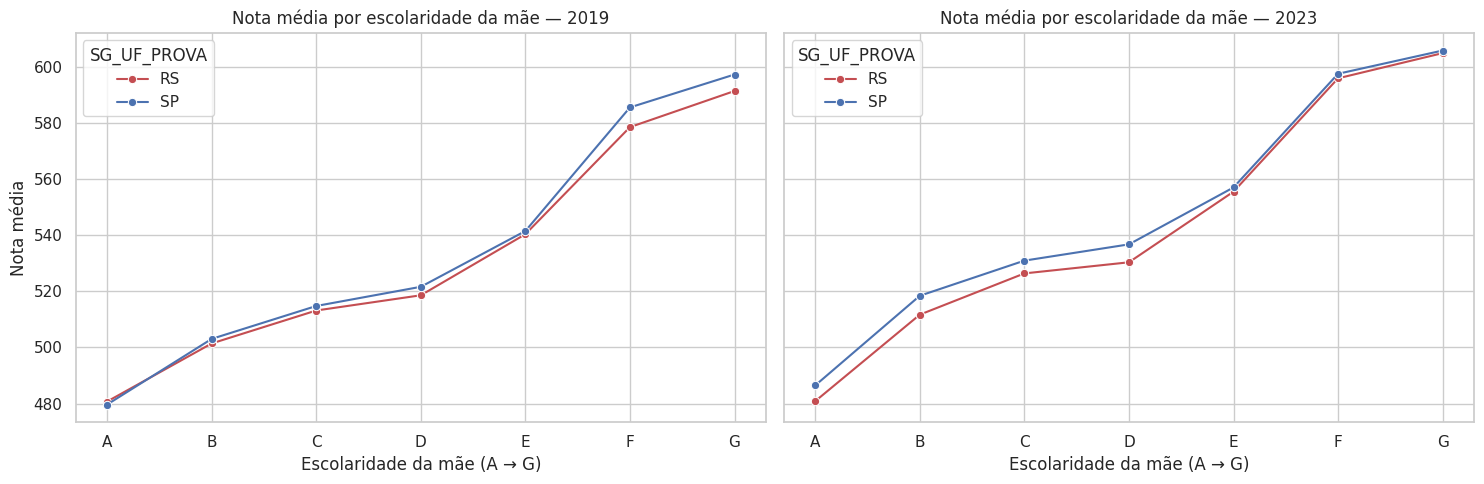

In [7]:
# Foco na escolaridade da mãe (Q002)
sub = df[df['Q002'].isin(escala)].copy()
medias = sub.groupby(['NU_ANO','SG_UF_PROVA','Q002'])['NOTA_MEDIA'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, ano in zip(axes, [2019, 2023]):
    dados = medias[medias['NU_ANO']==ano]
    sns.lineplot(data=dados, x='Q002', y='NOTA_MEDIA', hue='SG_UF_PROVA',
                 marker='o', ax=ax, palette=['#C44E52','#4C72B0'])
    ax.set_title(f'Nota média por escolaridade da mãe — {ano}')
    ax.set_xlabel('Escolaridade da mãe (A → G)')
    ax.set_ylabel('Nota média')

plt.tight_layout()
plt.show()

## 4. Efeito por área de conhecimento (escolaridade da mãe)

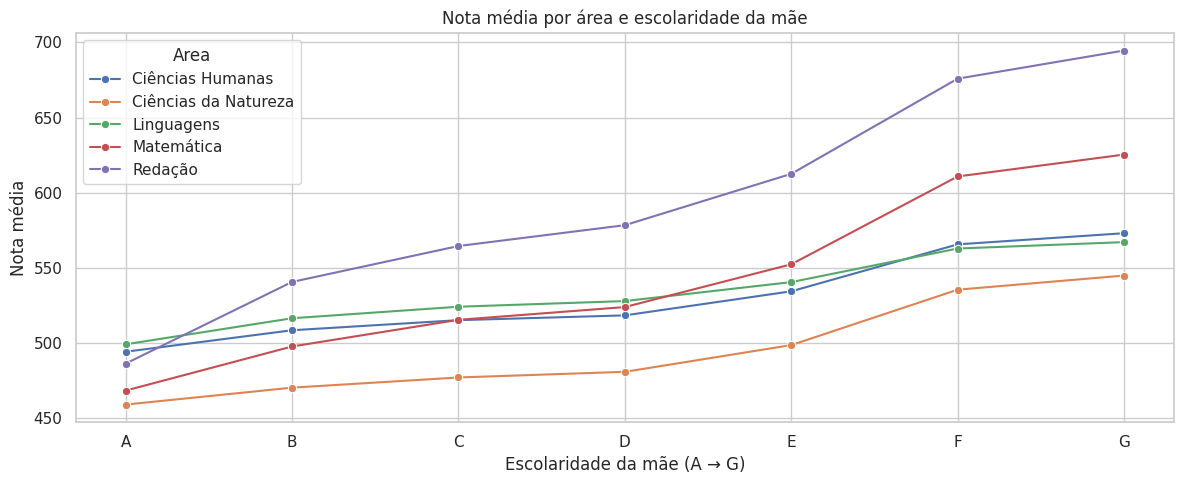


Gap G–A por área (escolaridade da mãe):
Q002                      A      G  Gap G–A
Area                                       
Redação               486.4  694.6    208.2
Matemática            468.4  625.4    157.0
Ciências da Natureza  459.1  545.0     85.8
Ciências Humanas      494.3  573.1     78.8
Linguagens            499.2  567.2     68.0


In [8]:
# Em qual área a escolaridade da mãe pesa mais?
areas_label = {'NU_NOTA_CN':'Ciências da Natureza', 'NU_NOTA_CH':'Ciências Humanas',
               'NU_NOTA_LC':'Linguagens', 'NU_NOTA_MT':'Matemática',
               'NU_NOTA_REDACAO':'Redação'}

sub = df[df['Q002'].isin(escala)].copy()
dados_area = sub.melt(id_vars=['Q002'], value_vars=list(areas_label.keys()),
                      var_name='Area', value_name='Nota')
dados_area['Area'] = dados_area['Area'].map(areas_label)
dados_area = dados_area.dropna(subset=['Nota'])

medias_area = dados_area.groupby(['Area','Q002'])['Nota'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(data=medias_area, x='Q002', y='Nota', hue='Area',
             marker='o', ax=ax)
ax.set_title('Nota média por área e escolaridade da mãe')
ax.set_xlabel('Escolaridade da mãe (A → G)')
ax.set_ylabel('Nota média')
plt.tight_layout()
plt.show()

# Gap por área
gap = medias_area.pivot(index='Area', columns='Q002', values='Nota')
gap['Gap G–A'] = (gap['G'] - gap['A']).round(1)
print("\nGap G–A por área (escolaridade da mãe):")
print(gap[['A','G','Gap G–A']].sort_values('Gap G–A', ascending=False).round(1).to_string())

## 5. Síntese dos achados

Registre aqui os principais achados. Sugestões do que descrever:

- A escolaridade dos pais tem efeito sobre o desempenho? Quão forte?
- O efeito da escolaridade da MÃE é maior, menor ou parecido com o do PAI?
- Há diferenças entre RS e SP?
- A relação mudou de 2019 para 2023?
- Em qual área de conhecimento o efeito é mais forte?